## 1. IMPORT LIBRARIES

<p><strong>Attribute Information:</strong></p>
<ul>
    <li><strong>CRIM</strong>: per capita crime rate by town</li>
    <li><strong>ZN</strong>: proportion of residential land zoned for lots over 25,000 sq.ft.</li>
    <li><strong>INDUS</strong>: proportion of non-retail business acres per town</li>
    <li><strong>CHAS</strong>: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)</li>
    <li><strong>NOX</strong>: nitric oxides concentration (parts per 10 million)</li>
    <li><strong>RM</strong>: average number of rooms per dwelling</li>
    <li><strong>AGE</strong>: proportion of owner-occupied units built prior to 1940</li>
    <li><strong>DIS</strong>: weighted distances to five Boston employment centres</li>
    <li><strong>RAD</strong>: index of accessibility to radial highways</li>
    <li><strong>TAX</strong>: full-value property-tax rate per 10,000</li>
    <li><strong>PTRATIO</strong>: pupil-teacher ratio by town</li>
    <li><strong>B</strong>: 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town</li>
    <li><strong>LSTAT</strong>: % lower status of the population</li>
    <li><strong>MEDV</strong>: Median value of owner-occupied homes in 1000's</li>
</ul>

In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
import numpy as np

## 2. IMPORT DATA FROM RAW

In [113]:
train = pd.read_csv(r"..\data\raw\train.csv")

In [114]:
print("\n\ntrain :\n\n", train.head(5))



train :

    ID     crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0   1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1   2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2   4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
3   5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
4   7  0.08829  12.5   7.87     0  0.524  6.012  66.6  5.5605    5  311   

   ptratio   black  lstat  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     18.7  394.63   2.94  33.4  
3     18.7  396.90   5.33  36.2  
4     15.2  395.60  12.43  22.9  


## 3. DATA EXPLORATION

### 3.1 DATA INFO

In [115]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       333 non-null    int64  
 1   crim     333 non-null    float64
 2   zn       333 non-null    float64
 3   indus    333 non-null    float64
 4   chas     333 non-null    int64  
 5   nox      333 non-null    float64
 6   rm       333 non-null    float64
 7   age      333 non-null    float64
 8   dis      333 non-null    float64
 9   rad      333 non-null    int64  
 10  tax      333 non-null    int64  
 11  ptratio  333 non-null    float64
 12  black    333 non-null    float64
 13  lstat    333 non-null    float64
 14  medv     333 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 39.2 KB


<p>IMPOTANT - There are not empty values in the file</p>

### 3.2 DATA DISPERSION -- LOOKING FOR OUTLIERS

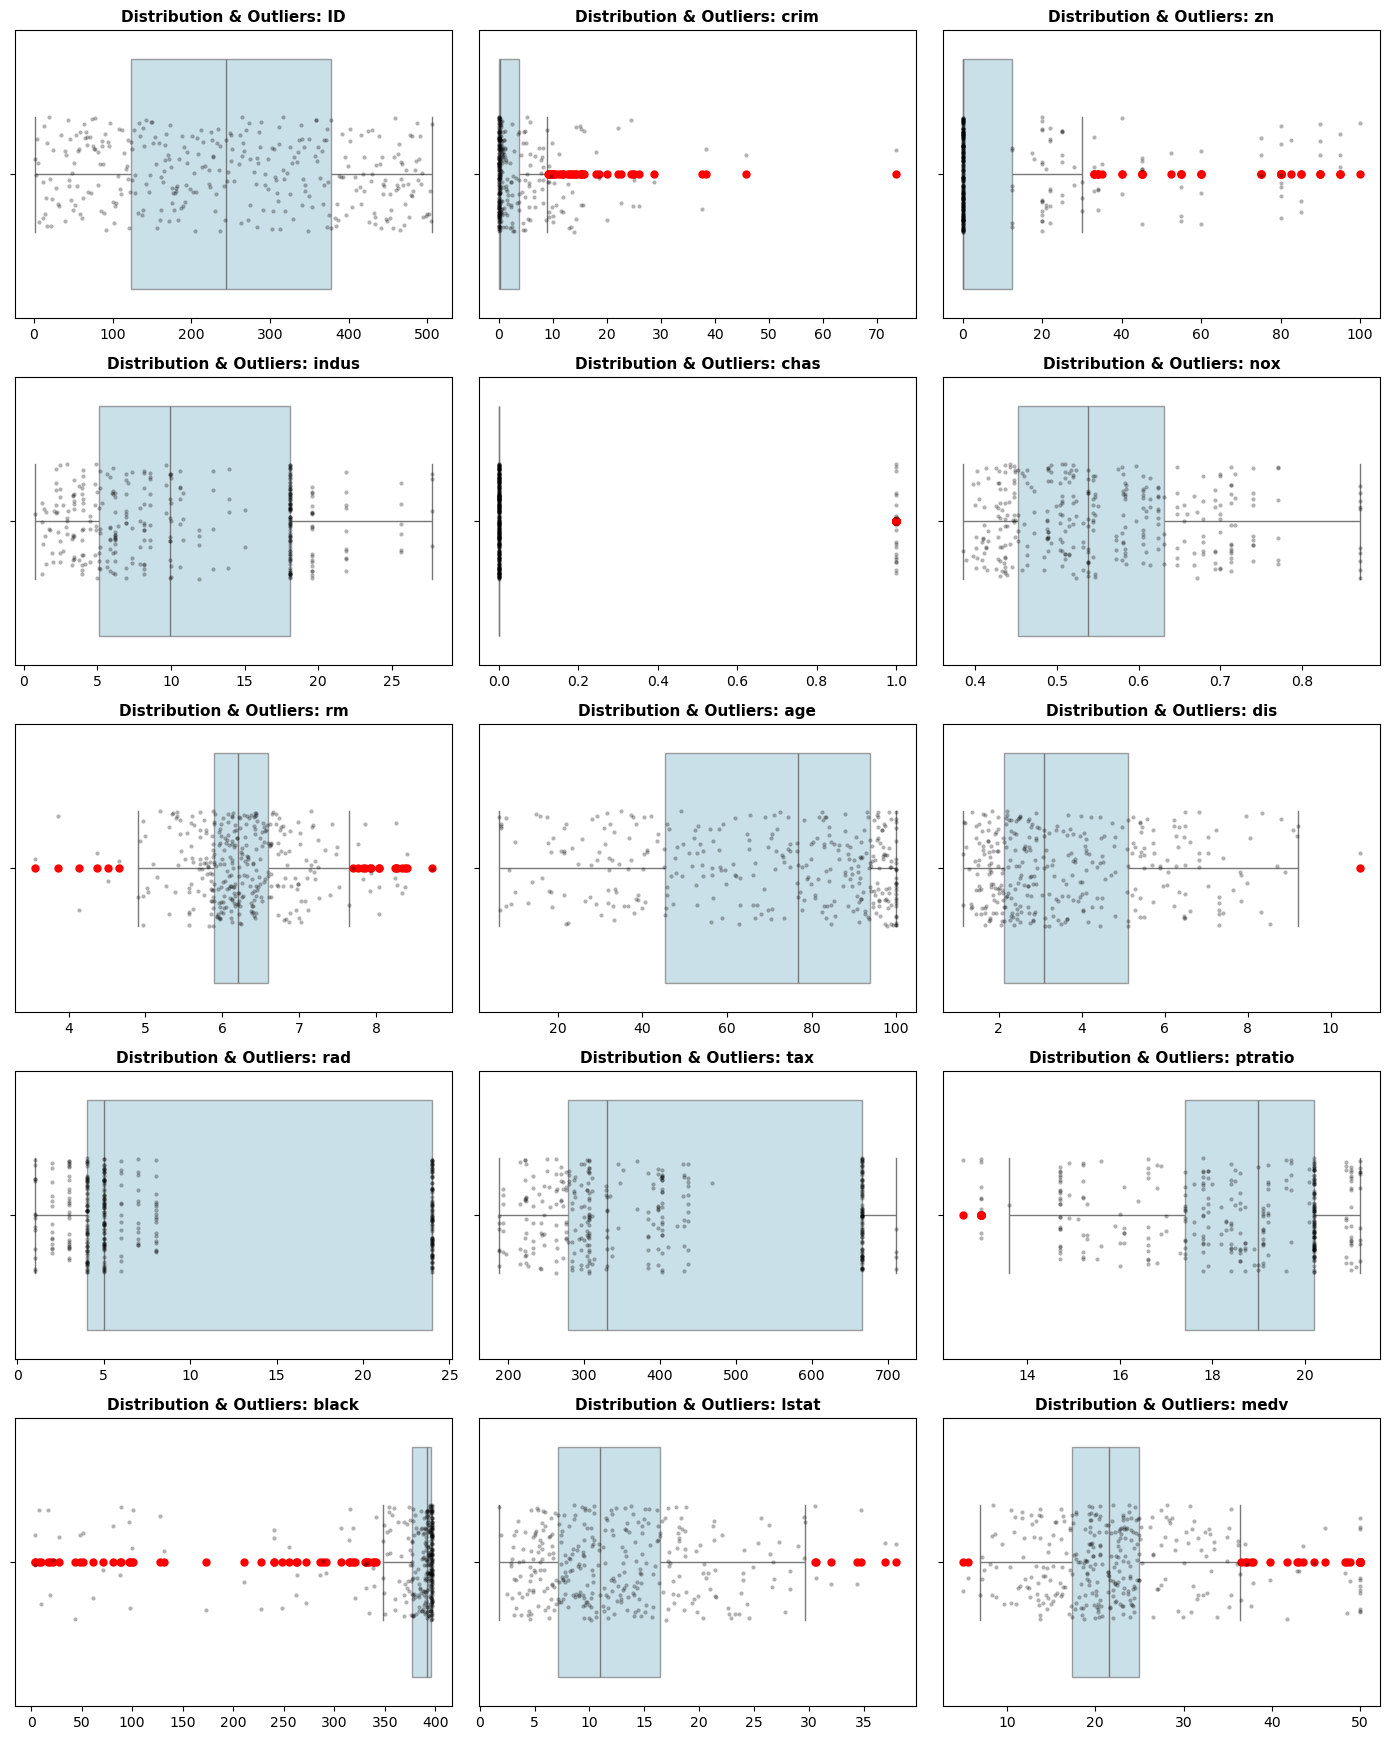

In [116]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
num_cols = len(numeric_cols)
ncols = 3
nrows = (num_cols + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.5 * nrows))
axes = axes.flatten()

# 3. Iterate over each column and build the plot
for i, col in enumerate(numeric_cols):
    # Boxplot shows the IQR box and flags extreme outliers in red
    sns.boxplot(
        x=train[col],
        ax=axes[i],
        color='lightblue',
        fliersize=5,
        boxprops=dict(alpha=0.7),
        flierprops=dict(
            marker='o', markerfacecolor='red', markeredgecolor='red'
        ),
    )

    # Stripplot adds raw data points scattered with light jitter
    sns.stripplot(
        x=train[col], ax=axes[i], color='black', alpha=0.3, jitter=0.2, size=3
    )

    axes[i].set_title(
        f'Distribution & Outliers: {col}', fontsize=11, fontweight='bold'
    )
    axes[i].set_xlabel('')

# 4. Remove any unused subplot axes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.3 DATA DESCRIBE

In [117]:
train.describe()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,3.360341,10.689189,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,359.466096,12.515435,22.768769
std,147.859438,7.352272,22.674762,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,86.584567,7.067781,9.173468
min,1.000000,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,3.500000,1.730000,5.000000
25%,123.000000,0.078960,0.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,376.730000,7.180000,17.400000
50%,244.000000,0.261690,0.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,392.050000,10.970000,21.600000
75%,377.000000,3.678220,12.500000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,396.240000,16.420000,25.000000
max,506.000000,73.534100,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,396.900000,37.970000,50.000000


## 4. MODEL 1 CREATION - all variables

### 4.1 SEPARATE PREDICTORS AND TARGET

In [118]:
train.shape

(333, 15)

<p>Train has 333 records, 80 % of the records will be to train the model and the rest 20% will be to test the model</p>

<p>For the independent variables i will drop ID because it is not a calculated value, and also drop medv because it is the variable that the model will try to predict. </P>

In [119]:
X = train.drop(columns=["ID", "medv"])
y = train["medv"]

<P> Now X is a dataframe that does not contain ID and medv</P>

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, ## 20 % of the records will be used for testing
    random_state=42
)

### 4.2 LINEAR REGRESSION MODEL

In [122]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [123]:
model1.intercept_

38.82886882002532

In [124]:
model1.coef_

array([-7.44192211e-02,  6.07808896e-02, -1.95671968e-02,  4.19687261e+00,
       -1.53062569e+01,  3.26393767e+00, -1.03353128e-02, -1.81461755e+00,
        3.86992613e-01, -1.45274344e-02, -7.41154093e-01,  7.74999988e-03,
       -6.33543844e-01])

In [125]:
weights = pd.DataFrame({
    "Variable": X.columns,
    "Weight": model1.coef_
})

weights

,Variable,Weight
0,crim,-0.074419
1,zn,0.060781
2,indus,-0.019567
3,chas,4.196873
4,nox,-15.306257
5,rm,3.263938
6,age,-0.010335
7,dis,-1.814618
8,rad,0.386993
9,tax,-0.014527


### 4.3 PREDICTIONS

In [126]:
predictions1 = model1.predict(X)
print(predictions1.size)
print(train.shape)
predictions1

333
(333, 15)


array([29.67537107, 23.98995008, 28.41271109, 27.31291419, 21.59420627,
       15.95754574, 19.68277726, 19.55892129, 19.99080505, 19.28314443,
       19.90651515, 21.61498095, 17.27302158, 11.74130901, 17.44211399,
       14.96575694, 12.8564295 , 14.05235495, 10.34075722, 17.72513625,
       12.94960679, 23.52348022, 32.54217391, 35.4863866 , 25.31135402,
       24.50141484, 22.31836165, 21.88170402, 19.72889779, 15.93572215,
       15.73903548, 20.00416119, 22.85937821, 23.5632186 , 14.88502314,
       31.16503373, 24.32179274, 32.87827241, 21.92808859, 17.34631028,
       17.58702332, 21.86126799, 21.51633999, 30.71666589, 25.40801474,
       20.84527047, 16.59733342, 25.17477985, 24.82911749, 24.03919822,
       25.63959921, 23.36304791, 21.85833   , 22.81294192, 28.64820052,
       26.68148037, 25.2294052 , 24.39179151, 27.63623668, 21.78032897,
       26.03089024, 30.29308869, 30.64798436, 27.04099002, 29.72742902,
       26.672033  , 24.28226785, 24.73884409, 25.97950815, 20.46

In [127]:
results = train.copy()
results["Model1_Prediction"] = predictions1
results

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,Model1_Prediction
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.675371
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,23.989950
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,28.412711
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,27.312914
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9,21.594206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,0.17783,0.0,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5,18.646467
329,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,23.895867
330,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,23.033384
331,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,28.075512


In [128]:
train

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,0.17783,0.0,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5
329,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
330,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
331,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9


## 5. MODEL 2 - removing ZN, INDUS, CHAS, AGE

In [132]:
X_2 = train.drop(columns=["ID", "medv", "zn", "indus", "chas", "age"])
X_2
y_2 = train["medv"]

In [133]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2,
    y_2,
    test_size=0.20, ## 20 % of the records will be used for testing
    random_state=42
)

In [134]:
model2 = LinearRegression()

model2.fit(X_train_2, y_train_2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [135]:
model2.intercept_

39.15139216249558

In [136]:
model2.coef_

array([-6.05338948e-02, -1.66284877e+01,  3.67687404e+00, -1.31899766e+00,
        4.01589443e-01, -1.33623375e-02, -1.00747926e+00,  8.90659641e-03,
       -6.45575981e-01])

In [137]:
weights_2 = pd.DataFrame({
    "Variable": X_2.columns,
    "Weight": model2.coef_
})

weights_2

,Variable,Weight
0,crim,-0.060534
1,nox,-16.628488
2,rm,3.676874
3,dis,-1.318998
4,rad,0.401589
5,tax,-0.013362
6,ptratio,-1.007479
7,black,0.008907
8,lstat,-0.645576


In [138]:
predictions2 = model2.predict(X_2)
print(predictions2.size)
print(train.shape)
predictions2

333
(333, 15)


array([30.33759421, 25.67941924, 30.28360625, 29.30653148, 23.24131593,
       18.33315838, 21.81909744, 20.77037738, 20.38131238, 19.803767  ,
       20.08718254, 21.57475445, 16.58431458, 11.73126288, 17.70887403,
       15.26539962, 13.14455562, 14.42774823, 10.52440514, 18.22655025,
       12.99032949, 23.605522  , 29.29309025, 32.38066716, 26.55123674,
       25.75106962, 23.82385152, 22.8571979 , 20.69499799, 17.77380944,
       17.39087464, 21.05649598, 24.19918061, 24.44026881, 11.9881794 ,
       29.00753133, 22.6849631 , 30.72102721, 22.51747398, 17.78852794,
       18.16669704, 22.90803341, 24.07155961, 28.34109145, 22.89528435,
       21.64336566, 17.37915438, 26.16574912, 25.7099254 , 24.93904222,
       26.32753824, 24.54459683, 23.07121589, 23.72642501, 28.50535384,
       26.85076716, 24.95771061, 25.46016146, 28.75043984, 22.44971228,
       26.58062775, 31.51385475, 31.65170644, 27.60067207, 28.61911332,
       26.0025665 , 24.94475254, 24.82113494, 26.05554873, 20.04

In [139]:
results["Model2_Prediction"] = predictions2
results

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv,Model1_Prediction,Model2_Prediction
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.675371,30.337594
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,23.989950,25.679419
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,28.412711,30.283606
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,27.312914,29.306531
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9,21.594206,23.241316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,0.17783,0.0,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5,18.646467,18.342038
329,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,23.895867,23.437024
330,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,23.033384,22.375595
331,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,28.075512,27.901123


## 6. COMPARING MODEL 1 VS MODEL 2

### 6.1 MAE

In [143]:
MAE_MOD_1 = mean_absolute_error(
    results["medv"],
    results["Model1_Prediction"]
)
MAE_MOD_2 = mean_absolute_error(
    results["medv"],
    results["Model2_Prediction"]
)
print(
    f"The mean absolute error of the model that uses all the variables is : {MAE_MOD_1} , \n"
    f"The mean absolute error of the model that did not use zn, indus, chas, age is : {MAE_MOD_2}"
)  


The mean absolute error of the model that uses all the variables is : 3.371585018013197 , 
The mean absolute error of the model that did not use zn, indus, chas, age is : 3.4759040163202215


### 6.2 MSE

In [145]:
from sklearn.metrics import mean_squared_error
MSE_MOD_1 = mean_squared_error(
    results["medv"],
    results["Model1_Prediction"]
)
MSE_MOD_2 = mean_squared_error(
    results["medv"],
    results["Model2_Prediction"]
)
print(
    f"The mean squared error of the model that uses all the variables is : {MSE_MOD_1} , \n"
    f"The mean squared error of the model that did not use zn, indus, chas, age is : {MSE_MOD_2}"
)  

The mean squared error of the model that uses all the variables is : 22.76606202693711 , 
The mean squared error of the model that did not use zn, indus, chas, age is : 23.98159617966195


### 6.3 RMSE

In [146]:
RMSE_MOD_1 = np.sqrt(MSE_MOD_1)
RMSE_MOD_2 = np.sqrt(MSE_MOD_2)
print(
    f"The root mean squared error of the model that uses all the variables is : {RMSE_MOD_1} , \n"
    f"The root mean squared error of the model that did not use zn, indus, chas, age is : {RMSE_MOD_2}"
)  

The root mean squared error of the model that uses all the variables is : 4.771379467925089 , 
The root mean squared error of the model that did not use zn, indus, chas, age is : 4.897100793292083


In [147]:
from sklearn.metrics import r2_score

r2_MOD_1 = r2_score(
    results["medv"],
    results["Model1_Prediction"]
)

r2_MOD_2 = r2_score(
    results["medv"],
    results["Model2_Prediction"]
)
print(
    f"The R2 of the model that uses all the variables is : {r2_MOD_1} , \n"
    f"The R2 of the model that did not use zn, indus, chas, age is : {r2_MOD_2}"
)  

The R2 of the model that uses all the variables is : 0.7286517898242276 , 
The R2 of the model that did not use zn, indus, chas, age is : 0.7141638640530008


## 7. SUMMARY

In [158]:
print(
    "SUMMARY\n"
    "ITEM\t\tMODEL 1\t\tMODEL 2\n"
    f"MAE\t\t{MAE_MOD_1:.3f}\t\t{MAE_MOD_2:.3f}\n"
    f"MSE\t\t{MSE_MOD_1:.3f}\t\t{MSE_MOD_2:.3f}\n"
    f"RMSE\t\t{RMSE_MOD_1:.3f}\t\t{RMSE_MOD_2:.3f}\n"
    f"R2\t\t{r2_MOD_1:.3f}\t\t{r2_MOD_2:.3f}\n"
    
)

SUMMARY
ITEM		MODEL 1		MODEL 2
MAE		3.372		3.476
MSE		22.766		23.982
RMSE		4.771		4.897
R2		0.729		0.714



<P>Model 1 outperformed Model 2 across all evaluation metrics. <BR>It achieved a lower MAE, MSE, and RMSE, indicating smaller prediction errors, and a higher R2, meaning it explained a larger proportion of the variability in house prices. Therefore, Model 1 is the preferred model for predicting the median value of homes in this dataset.</P>